How do you process the raw data into a form useful for your models? 
Will you have to do any featuring engineering or feature extraction? 
Does it need normalization? 
What to do with missing data? 
How to evaluate whether your train set and test set come from the same distribution, and what to do if they don't?

Understanding training data:
The following script analyzes data distribution and justifies why it is a useful dataset for the DRL Models.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

dow_30_stocks = ['MMM', 'AXP', 'AMGN', 'AMZN', 'AAPL', 'BA', 'CAT', 'CVX', 'CSCO', 'KO', 'DIS', 'GS', 'HD', 'HON', 'IBM', 'JNJ', 'JPM', 'MCD', 'MRK', 'MSFT', 'NKE', 'NVDA', 'PG', 'CRM', 'SHW', 'TRV', 'UNH', 'VZ', 'V', 'WMT']
tech_indicators = ['macd', 'boll_ub', 'boll_lb', 'rsi_14', 'rsi_30', 'cci_30', 'dx_30', 'close_30_sma', 'close_60_sma']

start_date = '2000-01-01'
end_date = '2025-08-01'

file_dir = (Path.cwd().parent/'datasets')
file_dir.mkdir(exist_ok=True)
train_file_path = file_dir / 'train.parquet'
test_file_path = file_dir / 'test.parquet'

train = pd.read_parquet(train_file_path)
test = pd.read_parquet(test_file_path)
print("Train and Test Datasets loaded successfully!")

train.info()
train_size = Path(train_file_path).stat().st_size
test_size = Path(test_file_path).stat().st_size

print(f"Current training datasize takes {train_size} bytes and {train_size / (1024*1024)} MegaBytes in memory.")
print(f"Current testing datasize takes {test_size} bytes and {test_size / (1024*1024)} MegaBytes in memory.")

Train and Test Datasets loaded successfully!
<class 'pandas.core.frame.DataFrame'>
Index: 144144 entries, 0 to 5147
Data columns (total 19 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Date          144144 non-null  datetime64[ns]
 1   Close         144144 non-null  float64       
 2   High          144144 non-null  float64       
 3   Low           144144 non-null  float64       
 4   Open          144144 non-null  float64       
 5   Volume        144144 non-null  int64         
 6   Stock         144144 non-null  object        
 7   Day           144144 non-null  int32         
 8   macd          144144 non-null  float64       
 9   boll_ub       144116 non-null  float64       
 10  boll_lb       144116 non-null  float64       
 11  rsi_14        144115 non-null  float64       
 12  rsi_30        144115 non-null  float64       
 13  cci_30        144116 non-null  float64       
 14  dx_30         144114 non-null 

Generic Basic Exploration

In [2]:
df = train
print(f"Dataset shape: {df.shape}\n")
print(f"Column names: \n{df.columns.tolist()}\n")
print(f"First 5 rows: \n{df.head()}\n")
print(f"Data Types: \n{df.dtypes}\n")

Dataset shape: (144144, 19)

Column names: 
['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Stock', 'Day', 'macd', 'boll_ub', 'boll_lb', 'rsi_14', 'rsi_30', 'cci_30', 'dx_30', 'close_30_sma', 'close_60_sma', 'VIX_Close', 'Turbulence']

First 5 rows: 
        Date      Close       High        Low       Open     Volume Stock  \
0 2000-01-03   0.840094   0.844316   0.763168   0.787090  535796800  AAPL   
0 2000-01-03  43.521145  48.404848  43.477926  48.404848   22914900  AMGN   
0 2000-01-03   4.468750   4.478125   3.952344   4.075000  322352000  AMZN   
0 2000-01-03  32.405487  33.899541  32.147892  33.899541    6471267   AXP   
0 2000-01-03  25.940283  26.908505  25.698227  26.747135    2638200    BA   

   Day  macd  boll_ub  boll_lb  rsi_14  rsi_30  cci_30  dx_30  close_30_sma  \
0    0   0.0      NaN      NaN     NaN     NaN     NaN    NaN      0.840094   
0    0   0.0      NaN      NaN     NaN     NaN     NaN    NaN     43.521145   
0    0   0.0      NaN      NaN     NaN     Na

Understanding basic details about this specific data:

In [3]:
print(f"{df['Stock'].nunique()} unique stocks in the dataset: \n{sorted(df['Stock'].unique())}\n")
print(f"Data Range of stock market:\n")
date = pd.to_datetime(df['Date'])
print(f"From {date.min()} to {date.max()}\n")
print(f"Total Trading days: {date.nunique()}\n")

28 unique stocks in the dataset: 
['AAPL', 'AMGN', 'AMZN', 'AXP', 'BA', 'CAT', 'CSCO', 'CVX', 'DIS', 'GS', 'HD', 'HON', 'IBM', 'JNJ', 'JPM', 'KO', 'MCD', 'MMM', 'MRK', 'MSFT', 'NKE', 'NVDA', 'PG', 'SHW', 'TRV', 'UNH', 'VZ', 'WMT']

Data Range of stock market:

From 2000-01-03 00:00:00 to 2020-06-18 00:00:00

Total Trading days: 5148



satistical summary of key features:
##FIXME: Can be further drawn into diagrams 

In [5]:
price_cols = ['Open','High','Low','Close']
print(f"Price Features OHLC: \n{df[price_cols].describe()}\n")
print(f"Volume Features: \n{df['Volume'].describe()}\n")
print(f"Technical Indicators Features: \n{df[tech_indicators].describe()}\n")

Price Features OHLC: 
                Open           High            Low          Close
count  144144.000000  144144.000000  144144.000000  144144.000000
mean       47.048457      47.506973      46.582005      47.056253
std        45.629233      46.052166      45.189115      45.631783
min         0.055780       0.060213       0.055016       0.056316
25%        17.295219      17.509053      17.066979      17.298060
50%        32.280480      32.646029      31.949660      32.293339
75%        63.080782      63.655301      62.511396      63.102938
max       435.563760     435.563760     429.880066     430.299988

Volume Features: 
count    1.441440e+05
mean     5.547656e+07
std      1.840643e+08
min      2.019000e+05
25%      4.407950e+06
50%      8.040000e+06
75%      1.885783e+07
max      9.230856e+09
Name: Volume, dtype: float64

Technical Indicators Features: 
                macd        boll_ub        boll_lb         rsi_14  \
count  144144.000000  144116.000000  144116.000000  144115

Comprehensive Data Distribution and Characteristics in visualization graphs

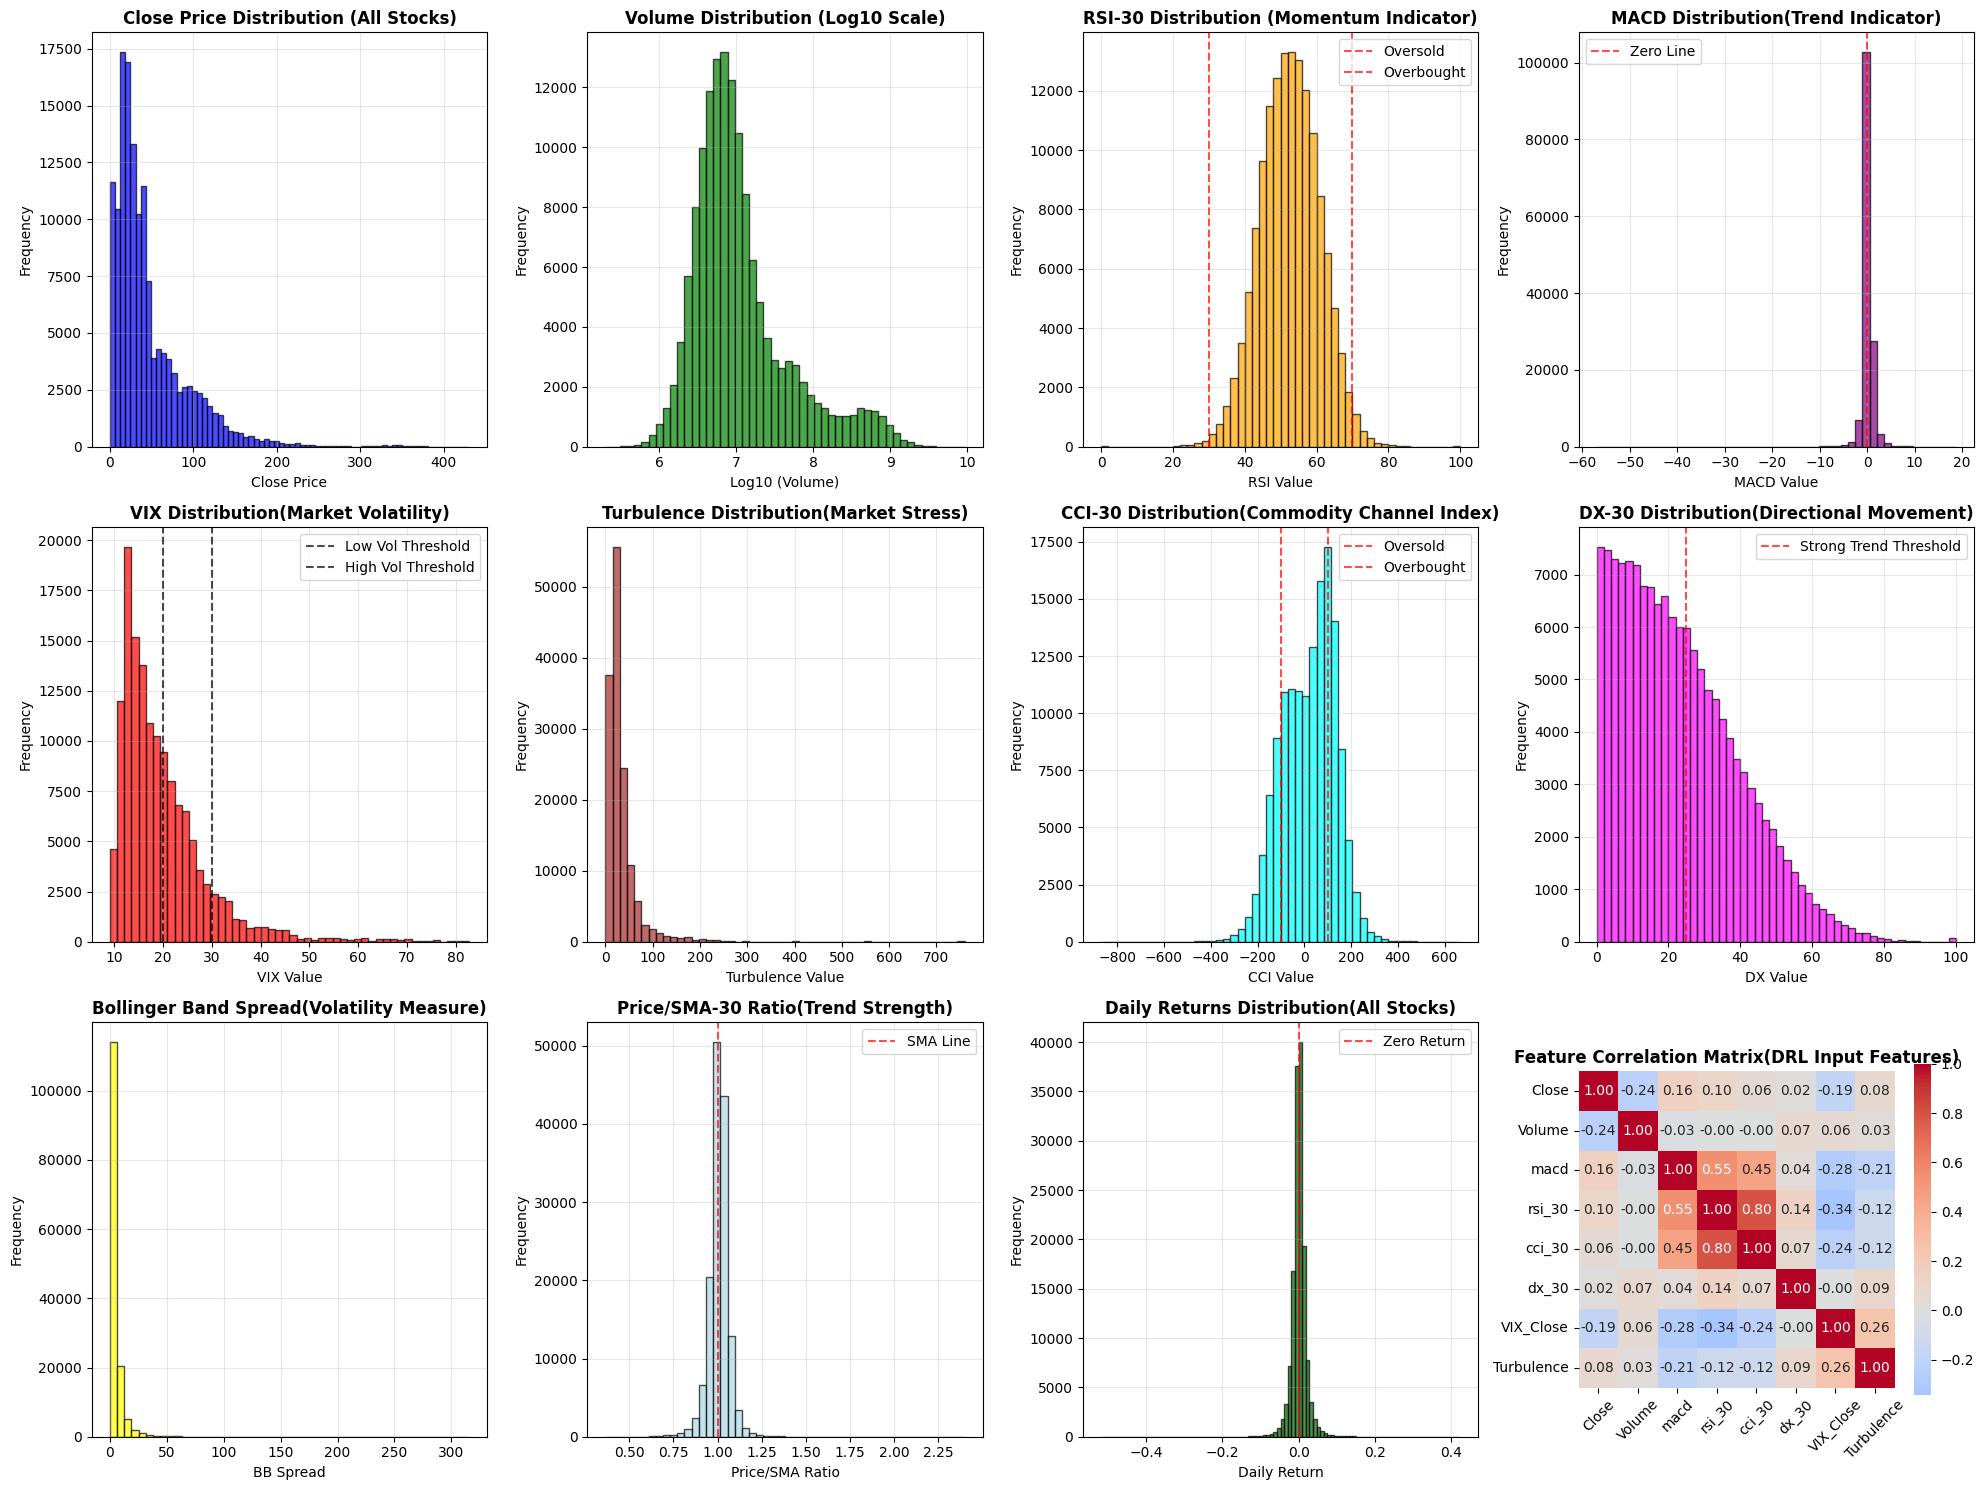

In [6]:
plt.style.use('default')
# create a high resolution, in pixels, reference: phone screen 1080x2400 pixels
fig=plt.figure(figsize=(20,15)) #<Figure size 2000x1500 with 0 Axes>

# 1. price distribution across all stocks
plt.subplot(3,4,1) #rows, columns, which position to select
n, bins, patches = plt.hist(df['Close'], bins=70, alpha=0.7, color='blue', edgecolor='black')
plt.title('Close Price Distribution (All Stocks)', fontsize=12, fontweight='bold')
plt.xlabel('Close Price')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

# 2. volume distribution (using log scale)
plt.subplot(3,4,2)
plt.hist(np.log10(df['Volume']), bins=50, alpha=0.7, color='green', edgecolor='black')
plt.title('Volume Distribution (Log10 Scale)',fontsize=12, fontweight='bold')
plt.xlabel('Log10 (Volume)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

# 3. RSI Distribution (key momentum indicator for DRL)
plt.subplot(3,4,3)
plt.hist(df['rsi_30'], bins=50, alpha=0.7, color='orange',edgecolor='black')
plt.title('RSI-30 Distribution (Momentum Indicator)',fontsize=12,fontweight='bold')
plt.xlabel('RSI Value')
plt.ylabel('Frequency')
plt.axvline(x=30,color='red',linestyle='--',alpha=0.7,label='Oversold')
plt.axvline(x=70, color='red', linestyle='--', alpha=0.7, label='Overbought')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. MACD distribution
plt.subplot(3, 4, 4)
plt.hist(df['macd'], bins=50, alpha=0.7, color='purple', edgecolor='black')
plt.title('MACD Distribution\
(Trend Indicator)', fontsize=12, fontweight='bold')
plt.xlabel('MACD Value')
plt.ylabel('Frequency')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Zero Line')
plt.legend()
plt.grid(True, alpha=0.3)

# 5. VIX distribution (market fear gauge)
plt.subplot(3, 4, 5)
plt.hist(df['VIX_Close'], bins=50, alpha=0.7, color='red', edgecolor='black')
plt.title('VIX Distribution\
(Market Volatility)', fontsize=12, fontweight='bold')
plt.xlabel('VIX Value')
plt.ylabel('Frequency')
plt.axvline(x=20, color='black', linestyle='--', alpha=0.7, label='Low Vol Threshold')
plt.axvline(x=30, color='black', linestyle='--', alpha=0.7, label='High Vol Threshold')
plt.legend()
plt.grid(True, alpha=0.3)

# 6. Turbulence distribution
plt.subplot(3, 4, 6)
plt.hist(df['Turbulence'], bins=50, alpha=0.7, color='brown', edgecolor='black')
plt.title('Turbulence Distribution\
(Market Stress)', fontsize=12, fontweight='bold')
plt.xlabel('Turbulence Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

# 7. CCI distribution
plt.subplot(3, 4, 7)
plt.hist(df['cci_30'], bins=50, alpha=0.7, color='cyan', edgecolor='black')
plt.title('CCI-30 Distribution\
(Commodity Channel Index)', fontsize=12, fontweight='bold')
plt.xlabel('CCI Value')
plt.ylabel('Frequency')
plt.axvline(x=-100, color='red', linestyle='--', alpha=0.7, label='Oversold')
plt.axvline(x=100, color='red', linestyle='--', alpha=0.7, label='Overbought')
plt.legend()
plt.grid(True, alpha=0.3)

# 8. DX distribution (Directional Movement Index)
plt.subplot(3, 4, 8)
plt.hist(df['dx_30'], bins=50, alpha=0.7, color='magenta', edgecolor='black')
plt.title('DX-30 Distribution\
(Directional Movement)', fontsize=12, fontweight='bold')
plt.xlabel('DX Value')
plt.ylabel('Frequency')
plt.axvline(x=25, color='red', linestyle='--', alpha=0.7, label='Strong Trend Threshold')
plt.legend()
plt.grid(True, alpha=0.3)

# 9. Bollinger Bands spread distribution
df['bb_spread'] = df['boll_ub'] - df['boll_lb']
plt.subplot(3, 4, 9)
plt.hist(df['bb_spread'], bins=50, alpha=0.7, color='yellow', edgecolor='black')
plt.title('Bollinger Band Spread\
(Volatility Measure)', fontsize=12, fontweight='bold')
plt.xlabel('BB Spread')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

# 10. Price vs SMA ratio (trend strength)
df['price_sma_ratio'] = df['Close'] / df['close_30_sma']
plt.subplot(3, 4, 10)
plt.hist(df['price_sma_ratio'], bins=50, alpha=0.7, color='lightblue', edgecolor='black')
plt.title('Price/SMA-30 Ratio\
(Trend Strength)', fontsize=12, fontweight='bold')
plt.xlabel('Price/SMA Ratio')
plt.ylabel('Frequency')
plt.axvline(x=1.0, color='red', linestyle='--', alpha=0.7, label='SMA Line')
plt.legend()
plt.grid(True, alpha=0.3)

# 11. Daily returns distribution
df_sorted = df.sort_values(['Stock', 'Date'])
df_sorted['daily_return'] = df_sorted.groupby('Stock')['Close'].pct_change()
plt.subplot(3, 4, 11)
returns_clean = df_sorted['daily_return'].dropna()
plt.hist(returns_clean, bins=100, alpha=0.7, color='darkgreen', edgecolor='black')
plt.title('Daily Returns Distribution\
(All Stocks)', fontsize=12, fontweight='bold')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Zero Return')
plt.legend()
plt.grid(True, alpha=0.3)

# 12. Correlation heatmap of key features
plt.subplot(3, 4, 12)
key_features = ['Close', 'Volume', 'macd', 'rsi_30', 'cci_30', 'dx_30', 'VIX_Close', 'Turbulence']
corr_matrix = df[key_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix\
(DRL Input Features)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Showing Moving Average Analysis:

Stocks in dataset:
['AAPL', 'AMGN', 'AMZN', 'AXP', 'BA', 'CAT', 'CSCO', 'CVX', 'DIS', 'GS', 'HD', 'HON', 'IBM', 'JNJ', 'JPM', 'KO', 'MCD', 'MMM', 'MRK', 'MSFT', 'NKE', 'NVDA', 'PG', 'SHW', 'TRV', 'UNH', 'VZ', 'WMT']
Total stocks: 28
Date range: 2000-01-03 00:00:00 to 2020-06-18 00:00:00
Total trading days: 5148


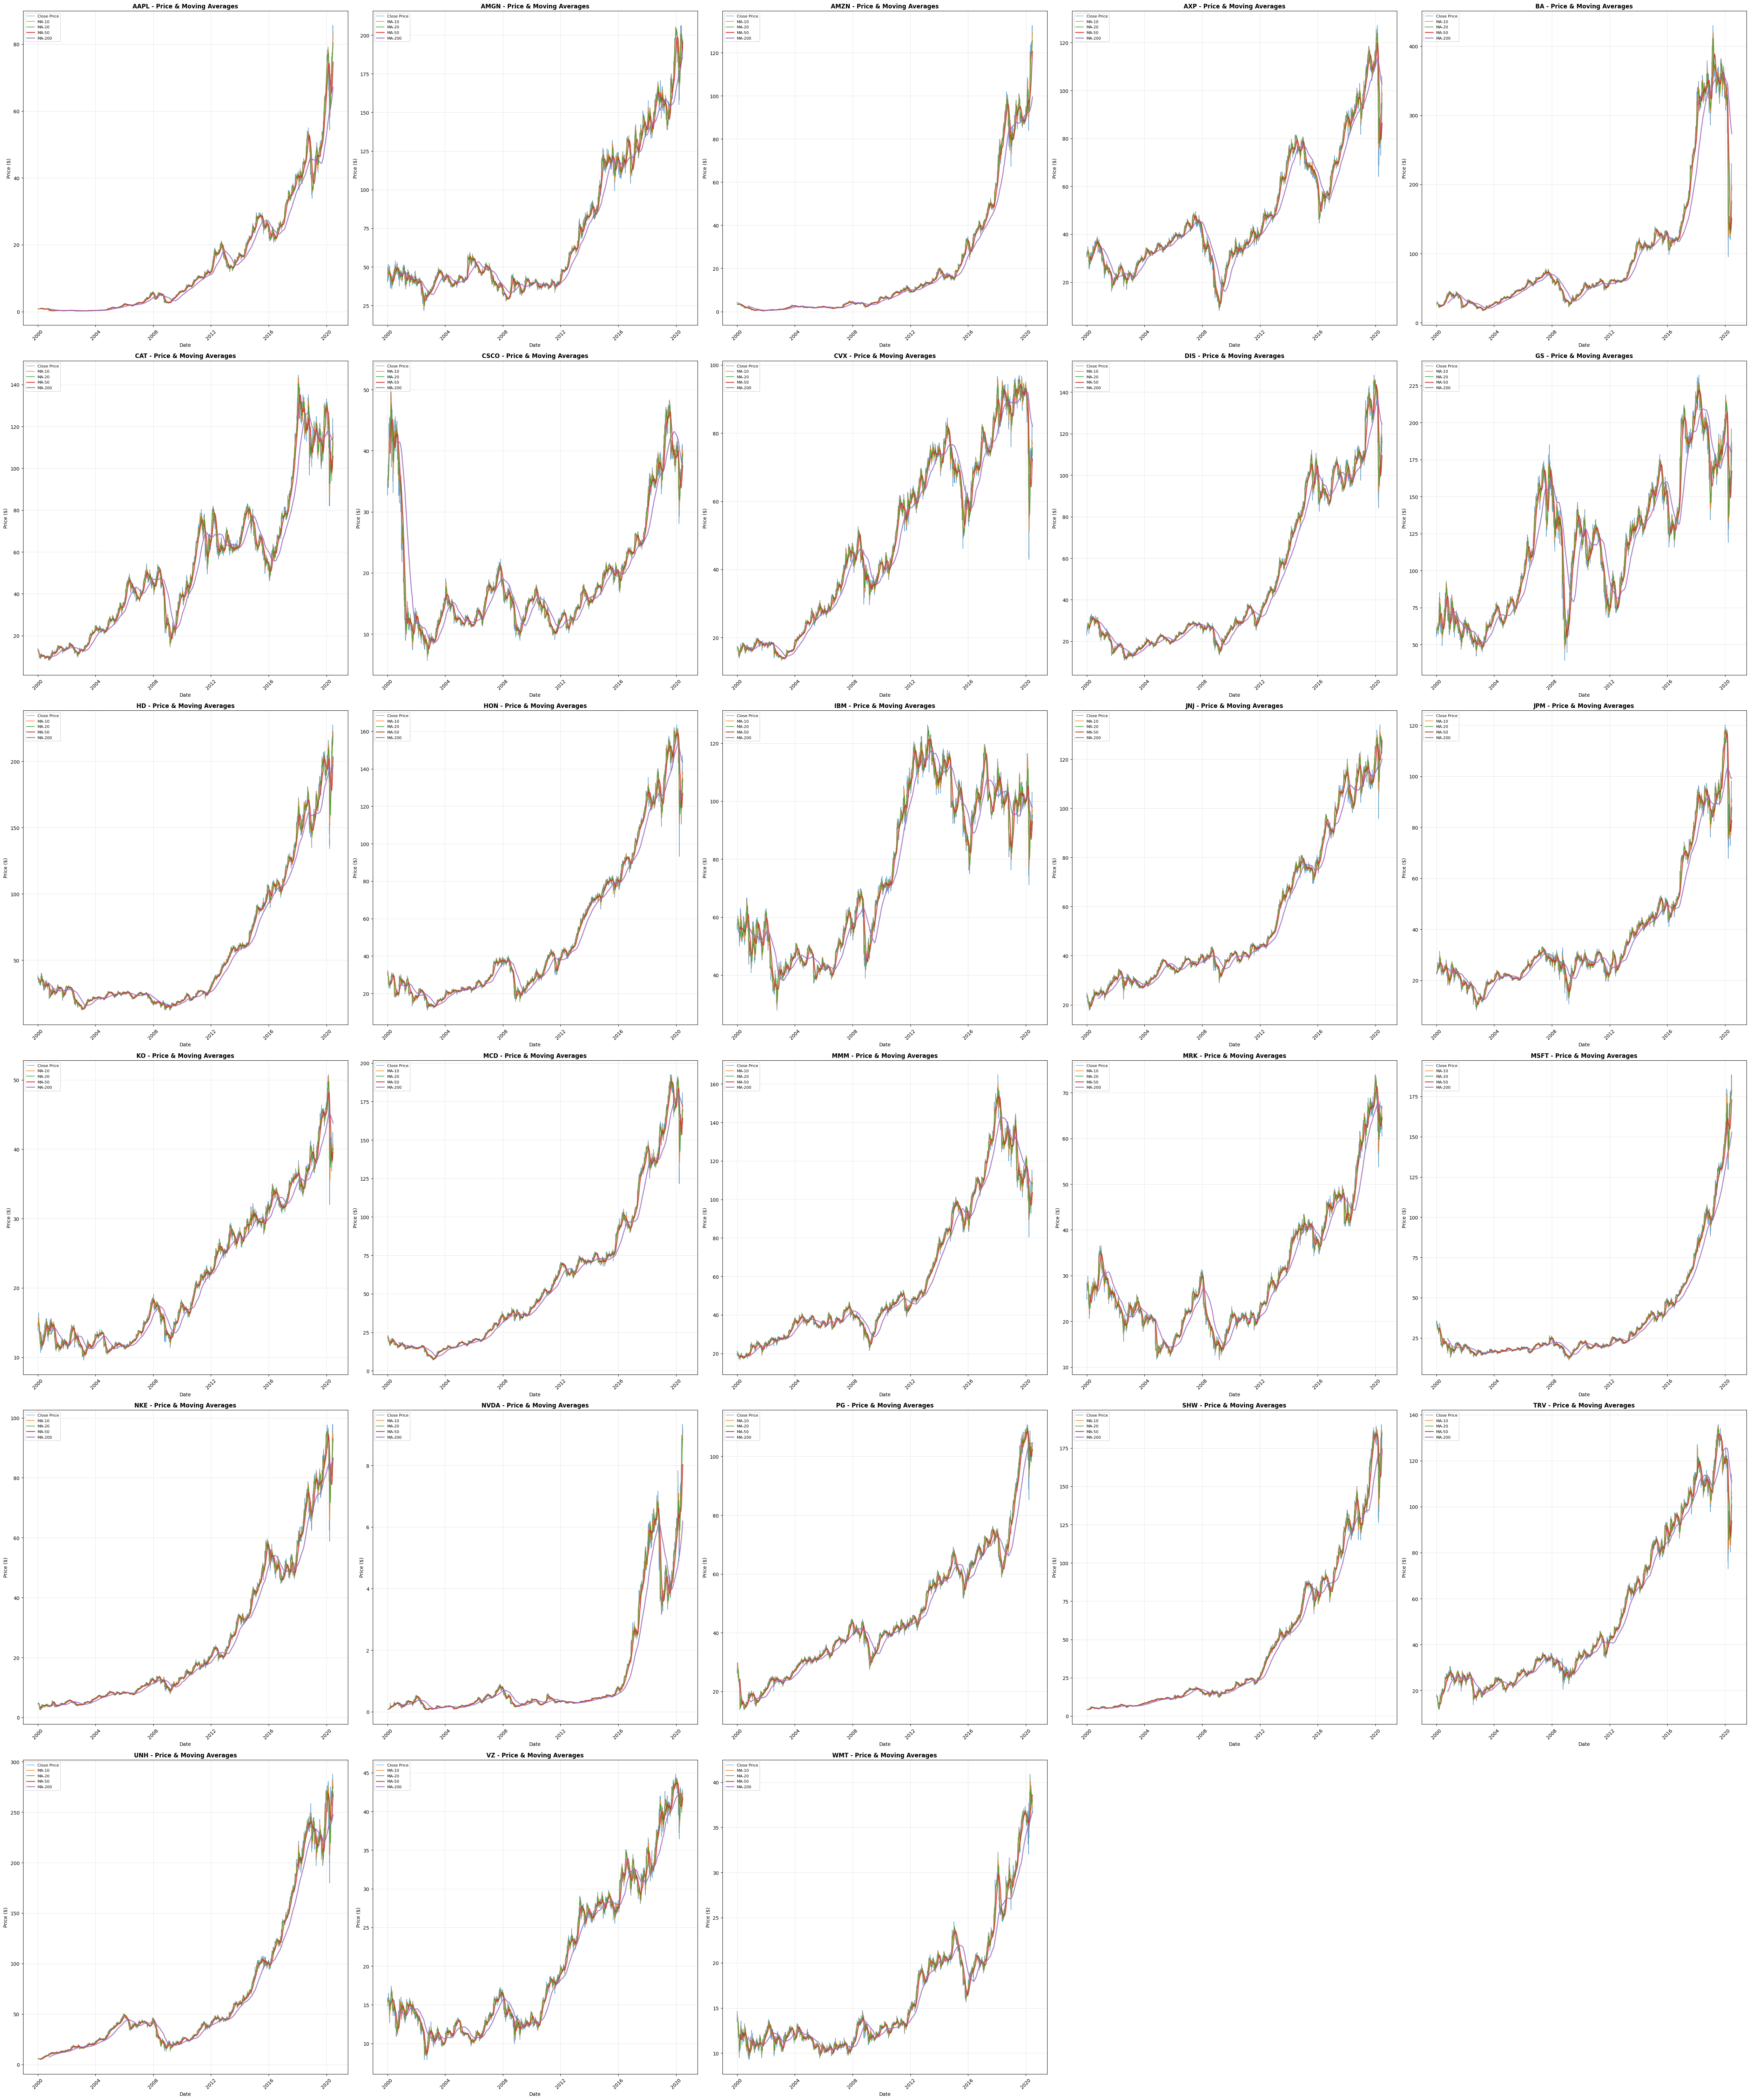

Individual stock moving averages plotted successfully!


In [7]:
# Create moving average analysis for all 28 stocks
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# First, let's see what stocks we have and prepare the data
print("Stocks in dataset:")
stocks = sorted(df['Stock'].unique())
print(stocks)
print(f"\
Total stocks: {len(stocks)}")

# Convert date to datetime for proper time series analysis
df['Date'] = pd.to_datetime(df['Date'])

# Sort by ticker and date to ensure proper time series order
df_sorted = df.sort_values(['Stock', 'Date']).reset_index(drop=True)

print(f"\
Date range: {df_sorted['Date'].min()} to {df_sorted['Date'].max()}")
print(f"Total trading days: {df_sorted['Date'].nunique()}")

# Create comprehensive moving average visualization
fig, axes = plt.subplots(6, 5, figsize=(50, 60))
axes = axes.flatten()

# Calculate additional moving averages for each stock
for i, stock in enumerate(stocks):
    stock_data = df_sorted[df_sorted['Stock'] == stock].copy()
    
    # Calculate different moving averages
    stock_data['ma_10'] = stock_data['Close'].rolling(window=10).mean()
    stock_data['ma_20'] = stock_data['Close'].rolling(window=20).mean()
    stock_data['ma_50'] = stock_data['Close'].rolling(window=50).mean()
    stock_data['ma_200'] = stock_data['Close'].rolling(window=200).mean()
    
    # Plot for each stock
    ax = axes[i]
    ax.plot(stock_data['Date'], stock_data['Close'], label='Close Price', alpha=0.7, linewidth=1)
    ax.plot(stock_data['Date'], stock_data['ma_10'], label='MA-10', alpha=0.8, linewidth=1.5)
    ax.plot(stock_data['Date'], stock_data['ma_20'], label='MA-20', alpha=0.8, linewidth=1.5)
    ax.plot(stock_data['Date'], stock_data['ma_50'], label='MA-50', alpha=0.8, linewidth=2)
    ax.plot(stock_data['Date'], stock_data['ma_200'], label='MA-200', alpha=0.8, linewidth=2)
    
    ax.set_title(f'{stock} - Price & Moving Averages', fontsize=12, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price ($)')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # Rotate x-axis labels for better readability
    ax.tick_params(axis='x', rotation=45)

# Remove empty subplot (we have 28 stocks, 30 subplots)
axes[28].remove()
axes[29].remove()

plt.tight_layout()
plt.show()

print("Individual stock moving averages plotted successfully!")

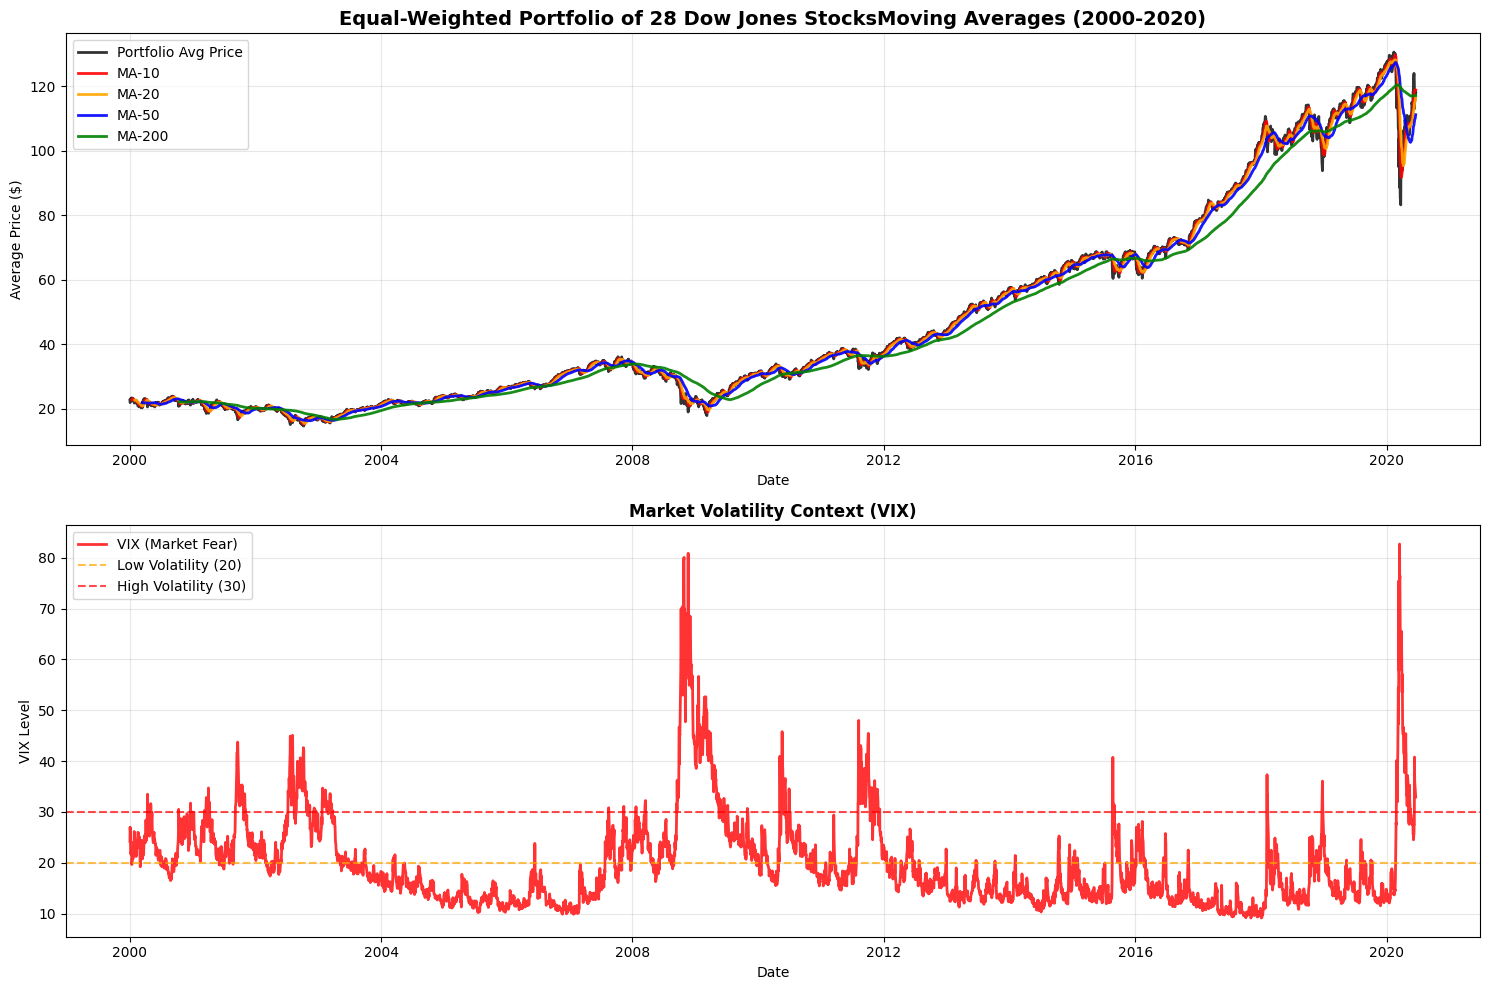

Portfolio Performance Summary (2000-2020):
Total Return: 419.9%
Price Range: $14.65 - $130.56
Average VIX: 19.8
Number of high volatility days (VIX > 30): 534
Number of low volatility days (VIX < 20): 3217


In [9]:
# Create an aggregate view showing average performance across all stocks
# Calculate portfolio-level moving averages

# Create equal-weighted portfolio
portfolio_data = df_sorted.groupby('Date').agg({
    'Close': 'mean',  # Average close price across all stocks
    'Volume': 'sum',  # Total volume
    'VIX_Close': 'first',   # VIX is market-wide
    'Turbulence': 'first'  # Turbulence is market-wide
}).reset_index()

# Calculate moving averages for the portfolio
portfolio_data['ma_10'] = portfolio_data['Close'].rolling(window=10).mean()
portfolio_data['ma_20'] = portfolio_data['Close'].rolling(window=20).mean()
portfolio_data['ma_50'] = portfolio_data['Close'].rolling(window=50).mean()
portfolio_data['ma_200'] = portfolio_data['Close'].rolling(window=200).mean()

# Create portfolio visualization
plt.figure(figsize=(15, 10))

# Main portfolio plot
plt.subplot(2, 1, 1)
plt.plot(portfolio_data['Date'], portfolio_data['Close'], label='Portfolio Avg Price', alpha=0.8, linewidth=2, color='black')
plt.plot(portfolio_data['Date'], portfolio_data['ma_10'], label='MA-10', alpha=0.9, linewidth=2, color='red')
plt.plot(portfolio_data['Date'], portfolio_data['ma_20'], label='MA-20', alpha=0.9, linewidth=2, color='orange')
plt.plot(portfolio_data['Date'], portfolio_data['ma_50'], label='MA-50', alpha=0.9, linewidth=2, color='blue')
plt.plot(portfolio_data['Date'], portfolio_data['ma_200'], label='MA-200', alpha=0.9, linewidth=2, color='green')

plt.title('Equal-Weighted Portfolio of 28 Dow Jones Stocks\
Moving Averages (2000-2020)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Average Price ($)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

# VIX overlay for market context
plt.subplot(2, 1, 2)
plt.plot(portfolio_data['Date'], portfolio_data['VIX_Close'], label='VIX (Market Fear)', color='red', alpha=0.8, linewidth=2)
plt.axhline(y=20, color='orange', linestyle='--', alpha=0.7, label='Low Volatility (20)')
plt.axhline(y=30, color='red', linestyle='--', alpha=0.7, label='High Volatility (30)')
plt.title('Market Volatility Context (VIX)', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('VIX Level')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate some key statistics
total_return = (portfolio_data['Close'].iloc[-1] / portfolio_data['Close'].iloc[0] - 1) * 100
max_price = portfolio_data['Close'].max()
min_price = portfolio_data['Close'].min()
avg_vix = portfolio_data['VIX_Close'].mean()

print(f"Portfolio Performance Summary (2000-2020):")
print(f"Total Return: {total_return:.1f}%")
print(f"Price Range: ${min_price:.2f} - ${max_price:.2f}")
print(f"Average VIX: {avg_vix:.1f}")
print(f"Number of high volatility days (VIX > 30): {(portfolio_data['VIX_Close'] > 30).sum()}")
print(f"Number of low volatility days (VIX < 20): {(portfolio_data['VIX_Close'] < 20).sum()}")